In [25]:
import pandas as pd

## 1. Loading dataset

In [26]:
music_data = pd.read_csv('music.csv')
music_data

,age,gender,genre
0,20.0,1,HipHop
1,23.0,1,HipHop
2,25.0,1,HipHop
3,26.0,1,Jazz
4,29.0,1,Jazz
5,30.0,1,Jazz
6,30.0,1,Jazz
7,31.0,1,Classical
8,33.0,1,Classical
9,37.0,1,Classical


In [27]:
music_data.shape

(21, 3)

## 2. Clean the data

### Remove duplicates

In [28]:
music_data[music_data.duplicated()]

,age,gender,genre
6,30.0,1,Jazz
19,35.0,0,Classical


In [29]:
# Before removing duplicates
music_data.shape

(21, 3)

In [30]:
# Remove duplicates
music_data = music_data.drop_duplicates()
# After removing duplicates
music_data.shape

(19, 3)

In [31]:
music_data

,age,gender,genre
0,20.0,1,HipHop
1,23.0,1,HipHop
2,25.0,1,HipHop
3,26.0,1,Jazz
4,29.0,1,Jazz
5,30.0,1,Jazz
7,31.0,1,Classical
8,33.0,1,Classical
9,37.0,1,Classical
10,20.0,0,Dance


### Impute missing values

# Check for missing values with imputer

In [32]:
from sklearn.impute import KNNImputer

In [12]:
imputer = KNNImputer(n_neighbors=3)
imputer.fit_transform(music_data)

ValueError: could not convert string to float: 'HipHop'

In [33]:
music_data['genre'].unique()

array(['HipHop', 'Jazz', 'Classical', 'Dance', 'Acoustic'], dtype=object)

The error you're encountering, `ValueError: could not convert string to float: 'HipHop'` occurs because the KNNImputer expects numerical input data, and it cannot handle string values.

## Encode data
Encode the string values in your target column into numerical values. Then apply KNNImputer to fill NaN values.

In [34]:
from sklearn.preprocessing import OneHotEncoder

In [35]:
enc = OneHotEncoder(handle_unknown='ignore', sparse_output=False).set_output(transform='pandas')

In [36]:
genre_transformed_data = enc.fit_transform(music_data[['genre']])
genre_transformed_data

,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,1.0
7,0.0,1.0,0.0,0.0,0.0
8,0.0,1.0,0.0,0.0,0.0
9,0.0,1.0,0.0,0.0,0.0
10,0.0,0.0,1.0,0.0,0.0


In [37]:
encoded_music_data = pd.concat([music_data, genre_transformed_data], axis=1).drop(columns=['genre'])
encoded_music_data

,age,gender,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
0,20.0,1,0.0,0.0,0.0,1.0,0.0
1,23.0,1,0.0,0.0,0.0,1.0,0.0
2,25.0,1,0.0,0.0,0.0,1.0,0.0
3,26.0,1,0.0,0.0,0.0,0.0,1.0
4,29.0,1,0.0,0.0,0.0,0.0,1.0
5,30.0,1,0.0,0.0,0.0,0.0,1.0
7,31.0,1,0.0,1.0,0.0,0.0,0.0
8,33.0,1,0.0,1.0,0.0,0.0,0.0
9,37.0,1,0.0,1.0,0.0,0.0,0.0
10,20.0,0,0.0,0.0,1.0,0.0,0.0


In [38]:
imputed_music_data = imputer.fit_transform(encoded_music_data)
imputed_music_data

array([[20.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ],
       [23.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ],
       [25.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  0.        ],
       [26.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ],
       [29.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ],
       [30.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  1.        ],
       [31.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ],
       [33.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ],
       [37.        ,  1.        ,  0.        ,  1.        ,  0.        ,
         0.        ,  0.        ],
       [20.        ,  0.    

In [39]:
imputed_music_data = pd.DataFrame(imputed_music_data, columns=encoded_music_data.columns)
imputed_music_data

,age,gender,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
0,20.000000,1.0,0.0,0.0,0.0,1.0,0.0
1,23.000000,1.0,0.0,0.0,0.0,1.0,0.0
2,25.000000,1.0,0.0,0.0,0.0,1.0,0.0
3,26.000000,1.0,0.0,0.0,0.0,0.0,1.0
4,29.000000,1.0,0.0,0.0,0.0,0.0,1.0
5,30.000000,1.0,0.0,0.0,0.0,0.0,1.0
6,31.000000,1.0,0.0,1.0,0.0,0.0,0.0
7,33.000000,1.0,0.0,1.0,0.0,0.0,0.0
8,37.000000,1.0,0.0,1.0,0.0,0.0,0.0
9,20.000000,0.0,0.0,0.0,1.0,0.0,0.0


In [40]:
imputed_music_data[imputed_music_data['genre_Classical'] == 1]

,age,gender,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
6,31.000000,1.0,0.0,1.0,0.0,0.0,0.0
7,33.000000,1.0,0.0,1.0,0.0,0.0,0.0
8,37.000000,1.0,0.0,1.0,0.0,0.0,0.0
15,31.000000,0.0,0.0,1.0,0.0,0.0,0.0
16,34.000000,0.0,0.0,1.0,0.0,0.0,0.0
17,35.000000,0.0,0.0,1.0,0.0,0.0,0.0
18,33.333333,0.0,0.0,1.0,0.0,0.0,0.0


In [23]:
imputed_music_data['age'] = imputed_music_data['age'].apply(lambda x: round(x))
imputed_music_data

,age,gender,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
0,20,1.0,0.0,0.0,0.0,1.0,0.0
1,23,1.0,0.0,0.0,0.0,1.0,0.0
2,25,1.0,0.0,0.0,0.0,1.0,0.0
3,26,1.0,0.0,0.0,0.0,0.0,1.0
4,29,1.0,0.0,0.0,0.0,0.0,1.0
5,30,1.0,0.0,0.0,0.0,0.0,1.0
6,31,1.0,0.0,1.0,0.0,0.0,0.0
7,33,1.0,0.0,1.0,0.0,0.0,0.0
8,37,1.0,0.0,1.0,0.0,0.0,0.0
9,20,0.0,0.0,0.0,1.0,0.0,0.0


## 3. Split dataset into train and test datasets

In [43]:
from sklearn.model_selection import train_test_split

# The inputs are known as features or ‘X variables’
X = imputed_music_data[['age', 'gender']]
X

,age,gender
0,20.000000,1.0
1,23.000000,1.0
2,25.000000,1.0
3,26.000000,1.0
4,29.000000,1.0
5,30.000000,1.0
6,31.000000,1.0
7,33.000000,1.0
8,37.000000,1.0
9,20.000000,0.0


In [44]:
# The output is known as the target or ‘y variable’
y = imputed_music_data.drop(columns=['age', 'gender'])
y

,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,0.0,0.0,1.0
5,0.0,0.0,0.0,0.0,1.0
6,0.0,1.0,0.0,0.0,0.0
7,0.0,1.0,0.0,0.0,0.0
8,0.0,1.0,0.0,0.0,0.0
9,0.0,0.0,1.0,0.0,0.0


### How much data do we need for training and testing?
There’s no “Golden Rule”. The amount of data you need depends on the complexity of the problem you’re trying to solve. However, a common rule of thumb is to split the data into 70% training and 30% testing.

### How to split the data?
[train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html#train-test-split) can be used to split the data into training and testing sets.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=10)

## 4. Create a model

What is a AI model?
- A model is a mathematical function or program trained with an <u> algorithm </u> on a <u> dataset </u> to identify patterns and make predictions on new data.
- A model is a set of rules that maps input data to a target output.


In [51]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier() # The Decision tree classifier is an algorithm

## 5. Train models

In [52]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

ValueError: x and y must be the same size

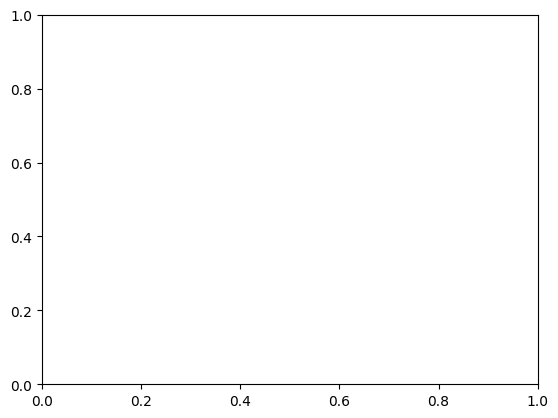

## 6. Make predictions

In [78]:
predictions = model.predict(X_test)
predictions

array([[0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [79]:
# Convert the data back to the original representation.
enc.inverse_transform(predictions)

array([['Jazz'],
       ['Classical'],
       ['Classical'],
       ['Jazz'],
       ['Classical'],
       ['HipHop']], dtype=object)

In [80]:
y_test

,genre_Acoustic,genre_Classical,genre_Dance,genre_HipHop,genre_Jazz
3,0,0,0,0,1
7,0,1,0,0,0
17,0,1,0,0,0
5,0,0,0,0,1
6,0,1,0,0,0
2,0,0,0,1,0


In [81]:
enc.inverse_transform(y_test)

array([['Jazz'],
       ['Classical'],
       ['Classical'],
       ['Jazz'],
       ['Classical'],
       ['HipHop']], dtype=object)

## 7. Evaluate

In [82]:
from sklearn.metrics import accuracy_score

accuracy_score  = accuracy_score(y_test, predictions)
accuracy_score

1.0